In [1]:
!pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d computingvictor/transactions-fraud-datasets

The syntax of the command is incorrect.
'cp' is not recognized as an internal or external command,
operable program or batch file.
'chmod' is not recognized as an internal or external command,
operable program or batch file.
Traceback (most recent call last):
  File "C:\Users\ahmed sadiwy\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\ahmed sadiwy\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\ahmed sadiwy\AppData\Local\Programs\Python\Python310\Scripts\kaggle.exe\__main__.py", line 5, in <module>
  File "C:\Users\ahmed sadiwy\AppData\Local\Programs\Python\Python310\lib\site-packages\kaggle\cli.py", line 68, in main
    out = args.func(**command_args)
  File "C:\Users\ahmed sadiwy\AppData\Local\Programs\Python\Python310\lib\site-packages\kaggle\api\kaggle_api_extended.py", line 1741, in dataset_download_cli
 

In [2]:
!unzip transactions-fraud-datasets.zip -d /content/

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:

transactions = pd.read_csv('C:\\Users\\ahmed sadiwy\\Downloads\\archive (2)\\transactions_data.csv')
cards        = pd.read_csv('C:\\Users\\ahmed sadiwy\\Downloads\\archive (2)\\cards_data.csv')
users        = pd.read_csv('C:\\Users\\ahmed sadiwy\\Downloads\\archive (2)\\users_data.csv')

with open('C:\\Users\\ahmed sadiwy\\Downloads\\archive (2)\\train_fraud_labels.json') as f:
    train_fraud_labels = json.load(f)

with open('C:\\Users\\ahmed sadiwy\\Downloads\\archive (2)\\mcc_codes.json') as f:
    mcc_codes = json.load(f)

print("Transactions:", transactions.shape)
print("Cards:       ", cards.shape)
print("Users:       ", users.shape)

Transactions: (13305915, 12)
Cards:        (6146, 13)
Users:        (2000, 14)


# ***Start Transactions_data.csv Cleaning & Analysis***

In [5]:
transactions.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


In [6]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            object 
 2   client_id       int64  
 3   card_id         int64  
 4   amount          object 
 5   use_chip        object 
 6   merchant_id     int64  
 7   merchant_city   object 
 8   merchant_state  object 
 9   zip             float64
 10  mcc             int64  
 11  errors          object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.2+ GB


In [7]:
#converting date in transaction to data_time
transactions['date']=pd.to_datetime(transactions['date'])

In [8]:
#converting amount to float for operations
transactions['amount']=transactions['amount'].str.replace('$',"",regex=False).astype(float)

In [9]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype         
---  ------          -----         
 0   id              int64         
 1   date            datetime64[ns]
 2   client_id       int64         
 3   card_id         int64         
 4   amount          float64       
 5   use_chip        object        
 6   merchant_id     int64         
 7   merchant_city   object        
 8   merchant_state  object        
 9   zip             float64       
 10  mcc             int64         
 11  errors          object        
dtypes: datetime64[ns](1), float64(2), int64(5), object(4)
memory usage: 1.2+ GB


In [10]:
transactions.isna().sum()

id                       0
date                     0
client_id                0
card_id                  0
amount                   0
use_chip                 0
merchant_id              0
merchant_city            0
merchant_state     1563700
zip                1652706
mcc                      0
errors            13094522
dtype: int64

In [11]:
#to know are values in merchant_state are missing values or logical missing values
NAN_state =transactions[transactions['merchant_state'].isna()]
NAN_state


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
7,7475335,2010-01-01 00:14:00,1684,2140,26.46,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN
8,7475336,2010-01-01 00:21:00,335,5131,261.58,Online Transaction,50292,ONLINE,NaN,NaN,7801,NaN
18,7475346,2010-01-01 00:34:00,394,4717,26.04,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN
24,7475353,2010-01-01 00:43:00,301,3742,10.17,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN
26,7475356,2010-01-01 00:45:00,566,3439,16.86,Online Transaction,16798,ONLINE,NaN,NaN,4121,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
13305879,23761832,2019-10-31 23:22:00,1556,2972,17.65,Online Transaction,88459,ONLINE,NaN,NaN,5311,NaN
13305880,23761833,2019-10-31 23:22:00,1797,5660,34.81,Online Transaction,15143,ONLINE,NaN,NaN,4784,NaN
13305888,23761843,2019-10-31 23:33:00,1069,5167,59.71,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN
13305897,23761853,2019-10-31 23:39:00,1422,5696,694.30,Online Transaction,70268,ONLINE,NaN,NaN,4722,NaN


In [12]:
NAN_state["use_chip" ].unique()

array(['Online Transaction', 'Chip Transaction'], dtype=object)

In [13]:
NAN_state["merchant_city" ].unique()

array(['ONLINE'], dtype=object)

In [14]:
NAN_state[NAN_state["use_chip"] == 'Chip Transaction']

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
6573529,15473515,2015-01-01 12:19:00,944,2828,-134.00,Chip Transaction,13348,ONLINE,NaN,NaN,4722,NaN
6573565,15473561,2015-01-01 12:27:00,944,2828,358.94,Chip Transaction,13348,ONLINE,NaN,NaN,4722,NaN
6573594,15473593,2015-01-01 12:32:00,1117,1162,117.43,Chip Transaction,52073,ONLINE,NaN,NaN,4722,NaN
6573677,15473695,2015-01-01 12:51:00,1117,1162,-147.00,Chip Transaction,52073,ONLINE,NaN,NaN,4722,NaN
6574120,15474225,2015-01-01 14:24:00,972,6052,233.77,Chip Transaction,13348,ONLINE,NaN,NaN,4722,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
13301848,23756824,2019-10-30 22:43:00,383,3686,160.82,Chip Transaction,90999,ONLINE,NaN,NaN,4722,NaN
13302226,23757266,2019-10-31 06:15:00,46,3513,-387.00,Chip Transaction,90999,ONLINE,NaN,NaN,4722,NaN
13302233,23757275,2019-10-31 06:16:00,46,3513,208.11,Chip Transaction,90999,ONLINE,NaN,NaN,4722,NaN
13305528,23761384,2019-10-31 20:03:00,1170,4592,129.47,Chip Transaction,13348,ONLINE,NaN,NaN,4722,NaN


In [15]:
#merchant_state was logical missing values and not missing values so do fillna with ONLINE in it
transactions.loc[
    transactions["merchant_city"] == "ONLINE", "merchant_state"
] = "ONLINE"

In [16]:
transactions.isna().sum()

id                       0
date                     0
client_id                0
card_id                  0
amount                   0
use_chip                 0
merchant_id              0
merchant_city            0
merchant_state           0
zip                1652706
mcc                      0
errors            13094522
dtype: int64

In [17]:
transactions["errors"].fillna("No Erros" , inplace=True)

C:\Users\ahmed sadiwy\AppData\Local\Temp\ipykernel_14296\3270932087.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  transactions["errors"].fillna("No Erros" , inplace=True)


In [18]:
transactions.head(5)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,No Erros
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,No Erros
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,No Erros
3,7475331,2010-01-01 00:05:00,430,2860,200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,No Erros
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,No Erros


In [19]:
# make sure ZIP values is missing values or logic missing values
NAN_zip=transactions[transactions['zip'].isna()]
NAN_zip

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
7,7475335,2010-01-01 00:14:00,1684,2140,26.46,Online Transaction,39021,ONLINE,ONLINE,NaN,4784,No Erros
8,7475336,2010-01-01 00:21:00,335,5131,261.58,Online Transaction,50292,ONLINE,ONLINE,NaN,7801,No Erros
18,7475346,2010-01-01 00:34:00,394,4717,26.04,Online Transaction,39021,ONLINE,ONLINE,NaN,4784,No Erros
24,7475353,2010-01-01 00:43:00,301,3742,10.17,Online Transaction,39021,ONLINE,ONLINE,NaN,4784,No Erros
26,7475356,2010-01-01 00:45:00,566,3439,16.86,Online Transaction,16798,ONLINE,ONLINE,NaN,4121,No Erros
...,...,...,...,...,...,...,...,...,...,...,...,...
13305879,23761832,2019-10-31 23:22:00,1556,2972,17.65,Online Transaction,88459,ONLINE,ONLINE,NaN,5311,No Erros
13305880,23761833,2019-10-31 23:22:00,1797,5660,34.81,Online Transaction,15143,ONLINE,ONLINE,NaN,4784,No Erros
13305888,23761843,2019-10-31 23:33:00,1069,5167,59.71,Online Transaction,39021,ONLINE,ONLINE,NaN,4784,No Erros
13305897,23761853,2019-10-31 23:39:00,1422,5696,694.30,Online Transaction,70268,ONLINE,ONLINE,NaN,4722,No Erros


In [20]:
NAN_zip['merchant_city'].unique()

array(['ONLINE', 'Puerto Vallarta', 'Vatican City', 'Guadalajara',
       'Santo Domingo', 'Montreal', 'Toronto', 'San Jose', 'Berlin',
       'Mexico City', 'Shanghai', 'Cancun', 'Edinburgh', 'Tallinn',
       'Funafuti', 'Tapei', 'Abu Dhabi', 'Beijing', 'Vilnius',
       'Amsterdam', 'Tokyo', 'Athens', 'Ho Chi Minh City',
       'Port au Prince', 'Dublin', 'Singapore', 'Paris', 'Johannesberg',
       'Cabo San Lucas', 'Bangkok', 'Rome', 'Copenhagen', 'Kingston',
       'Porto-Novo', 'London', 'Edmonton', 'Calgary', 'Brussels',
       'Freetown', 'Jakarta', 'Bogota', 'Geneva', 'Vancouver', 'Lisbon',
       'Wellington', 'Amman', 'Guatamala City', 'Hong Kong', 'Helsinki',
       'Ulan Bator', 'Riyadh', 'Manila', 'Oslo', 'Budapest', 'Seoul',
       'Jerusalem', 'Mumbai', 'Sydney', 'Monaco', 'Bucharest',
       'Saint Petersburg', 'Vienna', 'Majuro', 'Delhi', 'Barcelona',
       'Zurich', 'Oranjestad', 'Lima', 'Chisinau', 'Acapulco', 'Dhaka',
       'Madrid', 'Sao Paolo', 'Palikir', 'Tas

In [21]:
NAN_zip['merchant_state'].unique()

array(['ONLINE', 'Mexico', 'Vatican City', 'Dominican Republic', 'Canada',
       'Costa Rica', 'Germany', 'China', 'United Kingdom', 'Estonia',
       'Tuvalu', 'Taiwan', 'United Arab Emirates', 'Lithuania',
       'Netherlands', 'Japan', 'Greece', 'Vietnam', 'Haiti', 'Ireland',
       'Singapore', 'France', 'South Africa', 'Thailand', 'Italy',
       'Denmark', 'Jamaica', 'Benin', 'Belgium', 'Sierra Leone',
       'Indonesia', 'Colombia', 'Switzerland', 'Portugal', 'New Zealand',
       'Jordan', 'Guatemala', 'Hong Kong', 'Finland', 'Mongolia',
       'Saudi Arabia', 'Philippines', 'Norway', 'Hungary', 'South Korea',
       'Israel', 'India', 'Australia', 'Monaco', 'Romania', 'Russia',
       'Austria', 'Marshall Islands', 'Spain', 'Aruba', 'Peru', 'Moldova',
       'Bangladesh', 'Brazil', 'Micronesia', 'Uzbekistan', 'Chile',
       'Croatia', 'Sweden', 'Brunei', 'Antigua and Barbuda', 'Andorra',
       'Kenya', 'Czech Republic', 'Tonga', 'Eritrea', 'Solomon Islands',
       'Pakista

In [22]:
transactions.loc[transactions["merchant_city"] == "ONLINE" , "zip"] = 0

In [23]:
transactions.isna().sum()

id                    0
date                  0
client_id             0
card_id               0
amount                0
use_chip              0
merchant_id           0
merchant_city         0
merchant_state        0
zip               89006
mcc                   0
errors                0
dtype: int64

In [24]:
transactions["zip"][(transactions["merchant_city"] == "Puerto Vallarta") & (transactions["merchant_state"] == "Mexico")].unique()

array([nan])

In [25]:
# The Right Value By logic And Searchig
missing_zip = {
  "Puerto Vallarta": "48300",
  "Vatican City": "00120",
  "Guadalajara": "44100",
  "Santo Domingo": "10101",
  "Montreal": "H3A",
  "Toronto": "M5H",
  "San Jose": "10101",
  "Berlin": "10115",
  "Mexico City": "01000",
  "Shanghai": "200000",
  "Cancun": "77500",
  "Edinburgh": "EH1",
  "Tallinn": "10111",
  "Funafuti": "",
  "Tapei": "100",
  "Abu Dhabi": "00000",
  "Beijing": "100000",
  "Vilnius": "01100",
  "Amsterdam": "1011",
  "Tokyo": "100-0001",
  "Athens": "10552",
  "Ho Chi Minh City": "700000",
  "Port au Prince": "6110",
  "Dublin": "D01",
  "Singapore": "018989",
  "Paris": "75001",
  "Johannesberg": "",
  "Cabo San Lucas": "23450",
  "Bangkok": "10200",
  "Rome": "00184",
  "Copenhagen": "1050",
  "Kingston": "",
  "Porto-Novo": "",
  "London": "SW1A 1AA",
  "Edmonton": "T5J",
  "Calgary": "T2P",
  "Brussels": "1000",
  "Freetown": "",
  "Jakarta": "10110",
  "Bogota": "110111",
  "Geneva": "1201",
  "Vancouver": "V5K",
  "Lisbon": "1100-148",
  "Wellington": "6011",
  "Amman": "11118",
  "Guatamala City": "01001",
  "Hong Kong": "999077",
  "Helsinki": "00100",
  "Ulan Bator": "15160",
  "Riyadh": "12611",
  "Manila": "1000",
  "Oslo": "0150",
  "Budapest": "1051",
  "Seoul": "04524",
  "Jerusalem": "91000",
  "Mumbai": "400001",
  "Sydney": "2000",
  "Monaco": "98000",
  "Bucharest": "010011",
  "Saint Petersburg": "190000",
  "Vienna": "1010",
  "Majuro": "96960",
  "Delhi": "110001",
  "Barcelona": "08001",
  "Zurich": "8001",
  "Oranjestad": "",
  "Lima": "15001",
  "Chisinau": "MD-2001",
  "Acapulco": "39300",
  "Dhaka": "1000",
  "Madrid": "28001",
  "Sao Paulo": "01000-000",
  "Palikir": "96941",
  "Tashkent": "100000",
  "Santiago": "8320000",
  "Zagreb": "10000",
  "Kolkata": "700001",
  "Bangalore": "560001",
  "Rio de Janeiro": "20000-000",
  "Stockholm": "11120",
  "Bandar Seri Begawan": "BA1111",
  "Saint John's": "",
  "Andorra La Vella": "AD500",
  "Nairobi": "00100",
  "Prague": "110 00",
  "Nuku Alofa": "",
  "Asmara": "",
  "Honiara": "",
  "Islamabad": "44000",
  "Nassau": "",
  "Rabat": "10000",
  "Suva": "",
  "Muscat": "113",
  "Yaounde": "",
  "Skopje": "1000",
  "Tegucigalpa": "11101",
  "Abuja": "900001",
  "Belmopan": "",
  "Montevideo": "11000",
  "Istanbul": "34000",
  "Manama": "",
  "Moscow": "101000",
  "Kuala Lumpur": "50000",
  "Luxembourg": "L-1111",
  "Algiers": "16000",
  "Bridgetown": "BB11114",
  "Niamey": "",
  "Cairo": "11511",
  "Hanoi": "100000",
  "Accra": "00233",
  "Bratislava": "811 01",
  "Kiev": "01001",
  "Yaren District": "",
  "Buenos Aires": "C1000",
  "Juba": "",
  "Podgorica": "81000",
  "Colombo": "00100",
  "Lahore": "54000",
  "Reykjavik": "101",
  "Ljubljana": "1000",
  "Sanaa": "",
  "Riga": "LV-1050",
  "Doha": "00000",
  "Karachi": "74000",
  "Male": "20026",
  "Ouagadougou": "",
  "Harare": "",
  "Praia": "",
  "Malabo": "",
  "Port Vila": "",
  "Addis Ababa": "1000",
  "Mbabane": "",
  "Maputo": "1100",
  "Warsaw": "00-001",
  "Lusaka": "10101",
  "Kingstown": "",
  "Tblisi": "0105",
  "Baghdad": "10001",
  "Apia": "",
  "Monrovia": "1000",
  "Bamako": "",
  "Nicosia": "1010",
  "Quito": "170101",
  "Dakar": "",
  "Libreville": "",
  "Belgrade": "11000",
  "Tunis": "1000",
  "Pristina": "10000",
  "Bishek": "720001",
  "Victoria": "",
  "Sarajevo": "71000",
  "Panama City": "0819",
  "Paramaribo": "",
  "Yamoussoukro": "",
  "Yangon": "11181",
  "Tehran": "11369",
  "Beirut": "1107",
  "Valletta": "VLT 1117",
  "Tirana": "1001",
  "Conakry": "",
  "Port Moresby": "111",
  "Dili": "",
  "Caracas": "1010",
  "Khartoum": "11111",
  "Port of Spain": "",
  "Brazzaville": "",
  "Baku": "AZ1000",
  "Georgetown": ""
}

In [26]:
transactions['zip']=transactions['zip'].fillna(transactions['merchant_city'].map(missing_zip))

In [27]:
transactions.isna().sum()

id                  0
date                0
client_id           0
card_id             0
amount              0
use_chip            0
merchant_id         0
merchant_city       0
merchant_state      0
zip               434
mcc                 0
errors              0
dtype: int64

In [28]:
transactions['merchant_city'][transactions['zip'].isna()].unique()

array(['Sao Paolo'], dtype=object)

In [29]:
transactions['zip'].fillna("01000-000" , inplace= True)

C:\Users\ahmed sadiwy\AppData\Local\Temp\ipykernel_14296\3232381471.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  transactions['zip'].fillna("01000-000" , inplace= True)


In [30]:
transactions.isna().sum()

id                0
date              0
client_id         0
card_id           0
amount            0
use_chip          0
merchant_id       0
merchant_city     0
merchant_state    0
zip               0
mcc               0
errors            0
dtype: int64

# ***Missing Values Processing Completed for Transactions Dataset*** **bold text**

In [31]:
transactions.duplicated().sum()

0

# ***End Transactions_data.csv Cleaning & Analysis***

# ***#########################################################***

## ***Start Users_data.csv Cleaning***

In [32]:
users.head()

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1


In [33]:
def Time_left_until_retirement(users):
  current=users['current_age']
  retirement=users['retirement_age']
  if current>=retirement:
    return 'retired'
  return retirement-current
users['Time_left_until_retirement']=users.apply(Time_left_until_retirement,axis=1)

In [34]:
users.head()

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,Time_left_until_retirement
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5,13
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5,15
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5,retired
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4,retired
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1,27


In [35]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          2000 non-null   int64  
 1   current_age                 2000 non-null   int64  
 2   retirement_age              2000 non-null   int64  
 3   birth_year                  2000 non-null   int64  
 4   birth_month                 2000 non-null   int64  
 5   gender                      2000 non-null   object 
 6   address                     2000 non-null   object 
 7   latitude                    2000 non-null   float64
 8   longitude                   2000 non-null   float64
 9   per_capita_income           2000 non-null   object 
 10  yearly_income               2000 non-null   object 
 11  total_debt                  2000 non-null   object 
 12  credit_score                2000 non-null   int64  
 13  num_credit_cards            2000 

In [36]:
users['per_capita_income']=users['per_capita_income'].str.replace('$',"",regex=False).astype(float)

In [37]:
users['yearly_income']=users['yearly_income'].str.replace("$","",regex=False).astype(float)

In [38]:
users["total_debt"] = users["total_debt"].str.replace("$","" , regex= False).astype(float)

In [39]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          2000 non-null   int64  
 1   current_age                 2000 non-null   int64  
 2   retirement_age              2000 non-null   int64  
 3   birth_year                  2000 non-null   int64  
 4   birth_month                 2000 non-null   int64  
 5   gender                      2000 non-null   object 
 6   address                     2000 non-null   object 
 7   latitude                    2000 non-null   float64
 8   longitude                   2000 non-null   float64
 9   per_capita_income           2000 non-null   float64
 10  yearly_income               2000 non-null   float64
 11  total_debt                  2000 non-null   float64
 12  credit_score                2000 non-null   int64  
 13  num_credit_cards            2000 

In [40]:
users.isna().sum()

id                            0
current_age                   0
retirement_age                0
birth_year                    0
birth_month                   0
gender                        0
address                       0
latitude                      0
longitude                     0
per_capita_income             0
yearly_income                 0
total_debt                    0
credit_score                  0
num_credit_cards              0
Time_left_until_retirement    0
dtype: int64

## ***End Users_data.csv Cleaning***

# ***#########################################################***



# ***Start Cards_data.csv Cleaning***

In [41]:
cards.head()

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


In [42]:
cards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     6146 non-null   int64 
 1   client_id              6146 non-null   int64 
 2   card_brand             6146 non-null   object
 3   card_type              6146 non-null   object
 4   card_number            6146 non-null   int64 
 5   expires                6146 non-null   object
 6   cvv                    6146 non-null   int64 
 7   has_chip               6146 non-null   object
 8   num_cards_issued       6146 non-null   int64 
 9   credit_limit           6146 non-null   object
 10  acct_open_date         6146 non-null   object
 11  year_pin_last_changed  6146 non-null   int64 
 12  card_on_dark_web       6146 non-null   object
dtypes: int64(6), object(7)
memory usage: 624.3+ KB


In [43]:
cards['credit_limit']=cards['credit_limit'].str.replace('$',"",regex=False).astype(float)

In [44]:
cards['expires']=pd.to_datetime(cards['expires'])

C:\Users\ahmed sadiwy\AppData\Local\Temp\ipykernel_14296\2364193526.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cards['expires']=pd.to_datetime(cards['expires'])


In [45]:
cards['acct_open_date']=pd.to_datetime(cards['acct_open_date'])

C:\Users\ahmed sadiwy\AppData\Local\Temp\ipykernel_14296\1492811761.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cards['acct_open_date']=pd.to_datetime(cards['acct_open_date'])


In [46]:
cards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     6146 non-null   int64         
 1   client_id              6146 non-null   int64         
 2   card_brand             6146 non-null   object        
 3   card_type              6146 non-null   object        
 4   card_number            6146 non-null   int64         
 5   expires                6146 non-null   datetime64[ns]
 6   cvv                    6146 non-null   int64         
 7   has_chip               6146 non-null   object        
 8   num_cards_issued       6146 non-null   int64         
 9   credit_limit           6146 non-null   float64       
 10  acct_open_date         6146 non-null   datetime64[ns]
 11  year_pin_last_changed  6146 non-null   int64         
 12  card_on_dark_web       6146 non-null   object        
dtypes: 

In [47]:
cards['Account_End_Date']=cards['expires']-cards['acct_open_date']

In [48]:
cards.head()

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,Account_End_Date
0,4524,825,Visa,Debit,4344676511950444,2022-12-01,623,YES,2,24295.0,2002-09-01,2008,No,7396 days
1,2731,825,Visa,Debit,4956965974959986,2020-12-01,393,YES,2,21968.0,2014-04-01,2014,No,2436 days
2,3701,825,Visa,Debit,4582313478255491,2024-02-01,719,YES,2,46414.0,2003-07-01,2004,No,7520 days
3,42,825,Visa,Credit,4879494103069057,2024-08-01,693,NO,1,12400.0,2003-01-01,2012,No,7883 days
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,2009-03-01,75,YES,1,28.0,2008-09-01,2009,No,181 days


In [49]:
cards.isna().sum()

id                       0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
card_on_dark_web         0
Account_End_Date         0
dtype: int64

In [50]:
cards.duplicated().sum()

0

# ***End Cards_data.csv Cleaning***

# ***#########################################################***

# ***Start mcc_codess.json Cleaning***

In [51]:
mcc_codes = pd.read_json("C:\\Users\\ahmed sadiwy\\Downloads\\archive (2)\\mcc_codes.json", orient='index')
mcc_codes.reset_index(inplace=True)
mcc_codes.columns = ['MCC_Code', 'Description']
mcc_codes

,MCC_Code,Description
0,5812,Eating Places and Restaurants
1,5541,Service Stations
2,7996,"Amusement Parks, Carnivals, Circuses"
3,5411,"Grocery Stores, Supermarkets"
4,4784,Tolls and Bridge Fees
...,...,...
104,7549,Towing Services
105,5941,Sporting Goods Stores
106,5722,Household Appliance Stores
107,3009,Fabricated Structural Metal Products


In [52]:
mcc_codes.isna().sum()

MCC_Code       0
Description    0
dtype: int64

In [53]:
mcc_codes.duplicated().sum()

0

# ***End mcc_codess.json Cleaning***



# ***#########################################################***





# ***Start train_fraud_labels.json Cleaning***

In [54]:
train_fraud_labels=pd.read_json('C:\\Users\\ahmed sadiwy\\Downloads\\archive (2)\\train_fraud_labels.json')
train_fraud_labels.reset_index(inplace=True)
train_fraud_labels.columns = ["id", "Target"]
train_fraud_labels

,id,Target
0,10649266,No
1,23410063,No
2,9316588,No
3,12478022,No
4,9558530,No
...,...,...
8914958,14064699,No
8914959,7676538,No
8914960,15131030,No
8914961,17244732,No


In [55]:
train_fraud_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8914963 entries, 0 to 8914962
Data columns (total 2 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   Target  object
dtypes: int64(1), object(1)
memory usage: 136.0+ MB


In [56]:
train_fraud_labels['Target'].value_counts()

Target
No     8901631
Yes      13332
Name: count, dtype: int64

# ***End train_fraud_labels.json Cleaning***

# ***#########################################################***


#***Strat Merging for Analysis***

In [57]:
cards_users_merged=cards.merge(users,left_on='client_id',right_on='id')
cards_users_merged
# Merge cards with users to associate each card with its owner's user details
# left_on="client_id" (card's owner) matched with right_on="id" (user's id)


,id_x,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,...,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,Time_left_until_retirement
0,4524,825,Visa,Debit,4344676511950444,2022-12-01,623,YES,2,24295.0,...,Female,462 Rose Lane,34.15,-117.76,29278.0,59696.0,127613.0,787,5,13
1,2731,825,Visa,Debit,4956965974959986,2020-12-01,393,YES,2,21968.0,...,Female,462 Rose Lane,34.15,-117.76,29278.0,59696.0,127613.0,787,5,13
2,3701,825,Visa,Debit,4582313478255491,2024-02-01,719,YES,2,46414.0,...,Female,462 Rose Lane,34.15,-117.76,29278.0,59696.0,127613.0,787,5,13
3,42,825,Visa,Credit,4879494103069057,2024-08-01,693,NO,1,12400.0,...,Female,462 Rose Lane,34.15,-117.76,29278.0,59696.0,127613.0,787,5,13
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,2009-03-01,75,YES,1,28.0,...,Female,462 Rose Lane,34.15,-117.76,29278.0,59696.0,127613.0,787,5,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6141,5361,185,Amex,Credit,300609782832003,2024-01-01,663,YES,1,6900.0,...,Female,276 Fifth Boulevard,40.66,-74.19,15175.0,30942.0,71066.0,779,3,20
6142,2711,185,Visa,Credit,4718517475996018,2021-01-01,492,YES,2,5700.0,...,Female,276 Fifth Boulevard,40.66,-74.19,15175.0,30942.0,71066.0,779,3,20
6143,1305,1007,Mastercard,Credit,5929512204765914,2020-08-01,237,NO,2,9200.0,...,Male,259 Valley Boulevard,40.24,-76.92,25336.0,54654.0,27241.0,618,1,retired
6144,743,1110,Mastercard,Debit,5589768928167462,2020-01-01,630,YES,1,28074.0,...,Female,472 Ocean View Street,42.86,-71.48,32325.0,65909.0,181261.0,673,2,39


In [58]:
cards_transactions_merged =cards.merge(
    transactions,
    left_on=["id", "client_id"],
    right_on=["card_id", "client_id"]
)
cards_transactions_merged
# Merge cards with transactions using both card_id and client_id
# This ensures we only match transactions with the correct card and owner
# Prevents incorrect matches if different clients have similar card IDs

,id_x,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,...,date,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,4524,825,Visa,Debit,4344676511950444,2022-12-01,623,YES,2,24295.0,...,2010-01-02 16:41:00,4524,26.32,Swipe Transaction,54850,Mira Loma,CA,91752.0,4814,No Erros
1,4524,825,Visa,Debit,4344676511950444,2022-12-01,623,YES,2,24295.0,...,2010-01-03 06:54:00,4524,57.82,Swipe Transaction,50072,La Verne,CA,91750.0,5912,No Erros
2,4524,825,Visa,Debit,4344676511950444,2022-12-01,623,YES,2,24295.0,...,2010-01-03 11:58:00,4524,29.46,Swipe Transaction,69374,La Verne,CA,91750.0,5300,No Erros
3,4524,825,Visa,Debit,4344676511950444,2022-12-01,623,YES,2,24295.0,...,2010-01-04 06:08:00,4524,157.04,Swipe Transaction,61195,Mira Loma,CA,91752.0,5541,No Erros
4,4524,825,Visa,Debit,4344676511950444,2022-12-01,623,YES,2,24295.0,...,2010-01-04 16:43:00,4524,13.28,Swipe Transaction,81833,La Verne,CA,91750.0,5912,No Erros
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13305910,2711,185,Visa,Credit,4718517475996018,2021-01-01,492,YES,2,5700.0,...,2019-10-24 08:18:00,2711,1.95,Chip Transaction,75781,Elizabeth,NJ,7202.0,5411,No Erros
13305911,2711,185,Visa,Credit,4718517475996018,2021-01-01,492,YES,2,5700.0,...,2019-10-27 06:16:00,2711,3.02,Chip Transaction,25705,Elizabeth,NJ,7201.0,5411,No Erros
13305912,2711,185,Visa,Credit,4718517475996018,2021-01-01,492,YES,2,5700.0,...,2019-10-29 03:39:00,2711,-61.00,Chip Transaction,22204,Elizabeth,NJ,7201.0,5541,Technical Glitch
13305913,2711,185,Visa,Credit,4718517475996018,2021-01-01,492,YES,2,5700.0,...,2019-10-29 03:41:00,2711,61.00,Chip Transaction,22204,Elizabeth,NJ,7201.0,5541,No Erros


In [59]:
transactions_mcc_merged =mcc_codes.merge(transactions, left_on="MCC_Code", right_on="mcc")
transactions_mcc_merged
# Merge transactions with MCC codes to get the description of each transaction category
# This helps understand what type of business each transaction belongs to

,MCC_Code,Description,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,5812,Eating Places and Restaurants,7475370,2010-01-01 01:07:00,1963,3364,48.12,Swipe Transaction,88646,Vacaville,CA,95688.0,5812,No Erros
1,5812,Eating Places and Restaurants,7475373,2010-01-01 01:11:00,1642,4281,3.96,Swipe Transaction,44625,Manasquan,NJ,8736.0,5812,No Erros
2,5812,Eating Places and Restaurants,7475390,2010-01-01 01:41:00,247,4155,3.29,Swipe Transaction,92883,Lake Charles,LA,70605.0,5812,No Erros
3,5812,Eating Places and Restaurants,7475404,2010-01-01 01:56:00,1642,4281,3.35,Swipe Transaction,44625,Manasquan,NJ,8736.0,5812,No Erros
4,5812,Eating Places and Restaurants,7475423,2010-01-01 02:14:00,474,2493,91.02,Swipe Transaction,35451,Williston Park,NY,11596.0,5812,No Erros
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13305910,5733,Music Stores - Musical Instruments,23512035,2019-09-08 16:48:00,1028,342,2379.73,Swipe Transaction,41530,Chicago,IL,60623.0,5733,No Erros
13305911,5733,Music Stores - Musical Instruments,23582164,2019-09-23 14:30:00,1082,3308,385.40,Chip Transaction,10601,Parlier,CA,93648.0,5733,No Erros
13305912,5733,Music Stores - Musical Instruments,23747070,2019-10-28 16:50:00,1344,1044,450.00,Chip Transaction,59223,Sterling Heights,MI,48313.0,5733,No Erros
13305913,5733,Music Stores - Musical Instruments,23753730,2019-10-30 09:39:00,931,5847,319.09,Chip Transaction,72488,Memphis,TN,38118.0,5733,No Erros


In [60]:
transactions_labels_merged = train_fraud_labels.merge(transactions, on="id")
transactions_labels_merged
# Merge transactions with labels to include fraud/not-fraud information for each transaction
# on="id" ensures we match each label to the correct transaction


,id,Target,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,10649266,No,2012-01-26 13:17:00,11,243,14.01,Swipe Transaction,61195,Reisterstown,MD,21136.0,5541,No Erros
1,23410063,No,2019-08-18 08:33:00,609,2892,1.40,Chip Transaction,93214,Garland,TX,75040.0,5411,No Erros
2,9316588,No,2011-03-24 15:18:00,1094,138,16.83,Swipe Transaction,24504,Pellston,MI,49769.0,4214,No Erros
3,12478022,No,2013-03-15 21:51:00,944,2302,34.98,Swipe Transaction,82417,Palos Verdes Peninsula,CA,90274.0,4900,No Erros
4,9558530,No,2011-05-20 07:45:00,895,3483,9.62,Swipe Transaction,43293,Bloomington,CA,92316.0,5499,No Erros
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8914958,14064699,No,2014-02-28 07:13:00,321,5755,4.58,Swipe Transaction,20763,Merrill,WI,54452.0,5921,No Erros
8914959,7676538,No,2010-02-21 07:38:00,1435,4294,4.50,Swipe Transaction,50783,Auburn,GA,30011.0,5411,No Erros
8914960,15131030,No,2014-10-19 06:52:00,173,3528,84.77,Online Transaction,88459,ONLINE,ONLINE,0.0,5311,No Erros
8914961,17244732,No,2016-01-16 13:12:00,313,3153,9.62,Chip Transaction,47285,Bartlesville,OK,74003.0,7542,No Erros


#***End Merging of Analysis***

#***start Features from time***

> Add blockquote



In [61]:
transactions['hour']        = transactions['date'].dt.hour
transactions['day_of_week'] = transactions['date'].dt.dayofweek
transactions['month']       = transactions['date'].dt.month
transactions['is_weekend']  = transactions['day_of_week'].isin([5, 6]).astype(int)
transactions['is_night']    = transactions['hour'].between(0, 5).astype(int)

transactions[['date','hour','day_of_week','month','is_weekend','is_night']].head()

,date,hour,day_of_week,month,is_weekend,is_night
0,2010-01-01 00:01:00,0,4,1,0,1
1,2010-01-01 00:02:00,0,4,1,0,1
2,2010-01-01 00:02:00,0,4,1,0,1
3,2010-01-01 00:05:00,0,4,1,0,1
4,2010-01-01 00:06:00,0,4,1,0,1


In [62]:
client_stats = transactions.groupby('client_id')['amount'].agg(
    client_mean_amount  = 'mean',
    client_std_amount   = 'std',
    client_max_amount   = 'max',
    client_total_amount = 'sum',
    client_tx_count     = 'count'
).reset_index()

transactions = transactions.merge(client_stats, on='client_id', how='left')
transactions['amount_vs_client_mean'] = transactions['amount'] / (transactions['client_mean_amount'] + 1)

transactions[['client_id','amount','client_mean_amount','amount_vs_client_mean']].head()

,client_id,amount,client_mean_amount,amount_vs_client_mean
0,1556,-77.00,44.237594,-1.702124
1,561,14.57,26.853939,0.523086
2,1129,80.00,49.071079,1.597729
3,430,200.00,52.823266,3.715865
4,848,46.41,70.923255,0.645271


In [63]:
cards_features = cards[['id','client_id','credit_limit']].rename(columns={'id':'card_id'})

transactions = transactions.merge(cards_features, on=['card_id','client_id'], how='left')
transactions['amount_to_credit_ratio'] = transactions['amount'] / (transactions['credit_limit'] + 1)

transactions[['card_id','amount','credit_limit','amount_to_credit_ratio']].head()

,card_id,amount,credit_limit,amount_to_credit_ratio
0,2972,-77.00,55.0,-1.375000
1,4575,14.57,9100.0,0.001601
2,102,80.00,14802.0,0.005404
3,2860,200.00,37634.0,0.005314
4,3915,46.41,19113.0,0.002428


In [64]:
transactions['date_only'] = transactions['date'].dt.date

transactions['tx_count_same_day'] = transactions.groupby(
    ['client_id','date_only']
)['id'].transform('count')

transactions[['client_id','date_only','tx_count_same_day']].head()

,client_id,date_only,tx_count_same_day
0,1556,2010-01-01,6
1,561,2010-01-01,6
2,1129,2010-01-01,10
3,430,2010-01-01,10
4,848,2010-01-01,2


In [65]:
transactions['client_merchant_freq'] = transactions.groupby(
    ['client_id','merchant_id']
)['id'].transform('count')

transactions[['client_id','merchant_id','client_merchant_freq']].head()

,client_id,merchant_id,client_merchant_freq
0,1556,59935,826
1,561,67570,40
2,1129,27092,3464
3,430,27092,3411
4,848,13051,1555


In [66]:
transactions['is_online'] = (transactions['use_chip'] == 'Online Transaction').astype(int)
transactions['is_chip']   = (transactions['use_chip'] == 'Chip Transaction').astype(int)
transactions['is_swipe']  = (transactions['use_chip'] == 'Swipe Transaction').astype(int)
transactions['has_error'] = (transactions['errors'] != 'No Erros').astype(int)

transactions[['use_chip','is_online','is_chip','is_swipe','errors','has_error']].head()

,use_chip,is_online,is_chip,is_swipe,errors,has_error
0,Swipe Transaction,0,0,1,No Erros,0
1,Swipe Transaction,0,0,1,No Erros,0
2,Swipe Transaction,0,0,1,No Erros,0
3,Swipe Transaction,0,0,1,No Erros,0
4,Swipe Transaction,0,0,1,No Erros,0


In [67]:
final_df = transactions_labels_merged.merge(
    transactions[[
        'id','hour','day_of_week','month','is_weekend','is_night',
        'client_mean_amount','client_std_amount','client_max_amount',
        'client_tx_count','amount_vs_client_mean',
        'amount_to_credit_ratio','tx_count_same_day',
        'client_merchant_freq','is_online','is_chip','is_swipe',
        'has_error'
    ]],
    on='id', how='left'
)

print("✅ الـ Dataset النهائي جاهز!")
print("Shape:", final_df.shape)
final_df.head()

✅ الـ Dataset النهائي جاهز!
Shape: (8914963, 30)


,id,Target,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,...,client_max_amount,client_tx_count,amount_vs_client_mean,amount_to_credit_ratio,tx_count_same_day,client_merchant_freq,is_online,is_chip,is_swipe,has_error
0,10649266,No,2012-01-26 13:17:00,11,243,14.01,Swipe Transaction,61195,Reisterstown,MD,...,1540.17,9994,0.234966,0.000814,4,697,0,0,1,0
1,23410063,No,2019-08-18 08:33:00,609,2892,1.40,Chip Transaction,93214,Garland,TX,...,1504.62,8964,0.046925,0.000132,4,876,0,1,0,0
2,9316588,No,2011-03-24 15:18:00,1094,138,16.83,Swipe Transaction,24504,Pellston,MI,...,1308.24,5305,0.386067,0.007113,1,1042,0,0,1,0
3,12478022,No,2013-03-15 21:51:00,944,2302,34.98,Swipe Transaction,82417,Palos Verdes Peninsula,CA,...,2124.26,10401,0.334554,0.000523,4,53,0,0,1,0
4,9558530,No,2011-05-20 07:45:00,895,3483,9.62,Swipe Transaction,43293,Bloomington,CA,...,1281.20,8604,0.240540,0.000795,5,782,0,0,1,0


In [68]:
print(final_df.shape)

(8914963, 30)


In [69]:
import gc

# حذف الـ DataFrames الكبيرة اللي مش محتاجها
del cards_transactions_merged
del transactions_mcc_merged
del cards_users_merged

gc.collect()
print("✅ تم تحرير الذاكرة")

✅ تم تحرير الذاكرة


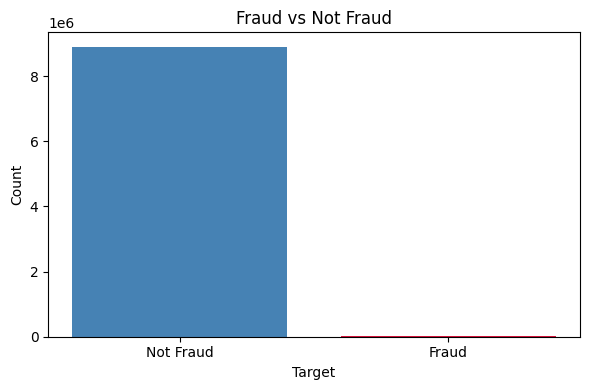

Target
No     8901631
Yes      13332
Name: count, dtype: int64

نسبة الـ Fraud: 0.15 %


C:\Users\ahmed sadiwy\AppData\Local\Temp\ipykernel_14296\1724534357.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("\nنسبة الـ Fraud:", round(counts[1]/counts.sum()*100, 2), "%")


In [70]:
# أسرع بكتير لأنها بتحسب مرة واحدة بس
counts = final_df['Target'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(['Not Fraud','Fraud'], counts.values, color=['steelblue','crimson'])
plt.title('Fraud vs Not Fraud')
plt.xlabel('Target')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(counts)
print("\nنسبة الـ Fraud:", round(counts[1]/counts.sum()*100, 2), "%")

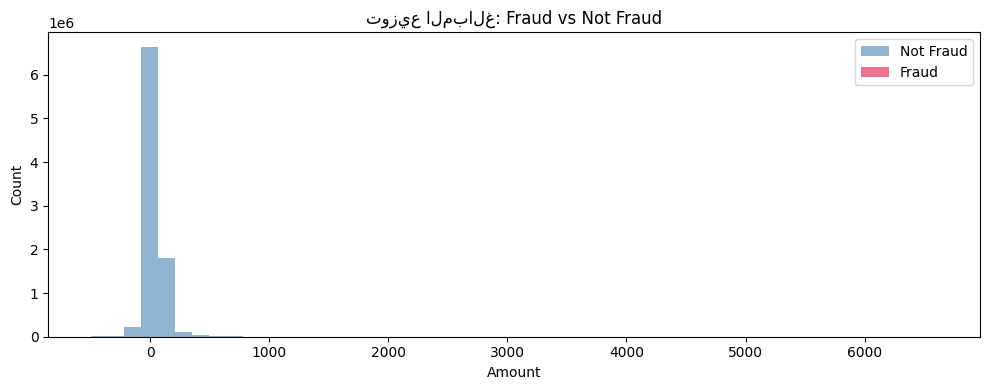

In [71]:
counts = final_df['Target'].value_counts()
fraud = final_df[final_df['Target'] == 'Yes']['amount']
not_fraud = final_df[final_df['Target'] == 'No']['amount']

plt.figure(figsize=(10,4))
plt.hist(not_fraud, bins=50, alpha=0.6, color='steelblue', label='Not Fraud')
plt.hist(fraud, bins=50, alpha=0.6, color='crimson', label='Fraud')
plt.title('توزيع المبالغ: Fraud vs Not Fraud')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

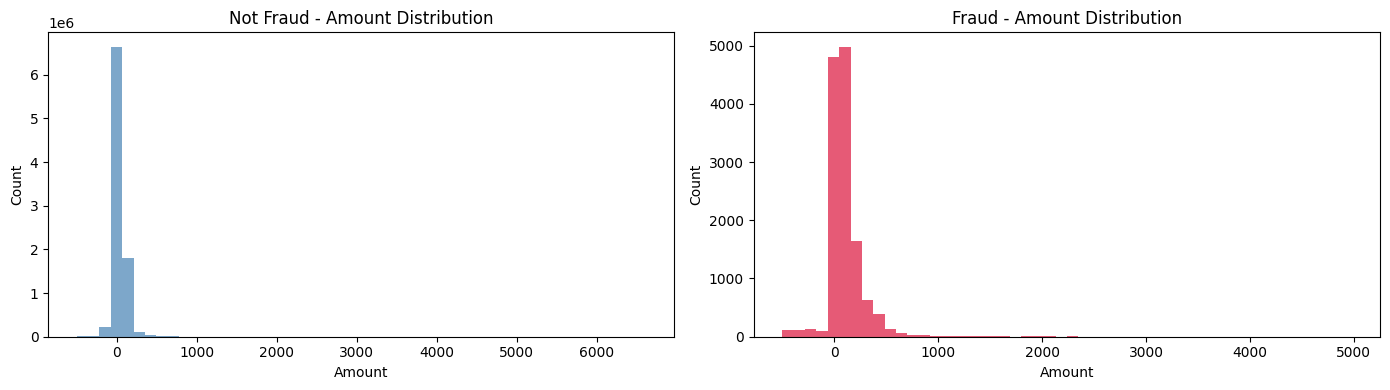

Not Fraud - متوسط المبلغ: 42.85
Fraud - متوسط المبلغ:     110.23


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))

fraud = final_df[final_df['Target'] == 'Yes']['amount']
not_fraud = final_df[final_df['Target'] == 'No']['amount']

# Not Fraud
axes[0].hist(not_fraud, bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('Not Fraud - Amount Distribution')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')

# Fraud
axes[1].hist(fraud, bins=50, color='crimson', alpha=0.7)
axes[1].set_title('Fraud - Amount Distribution')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("Not Fraud - متوسط المبلغ:", round(not_fraud.mean(), 2))
print("Fraud - متوسط المبلغ:    ", round(fraud.mean(), 2))

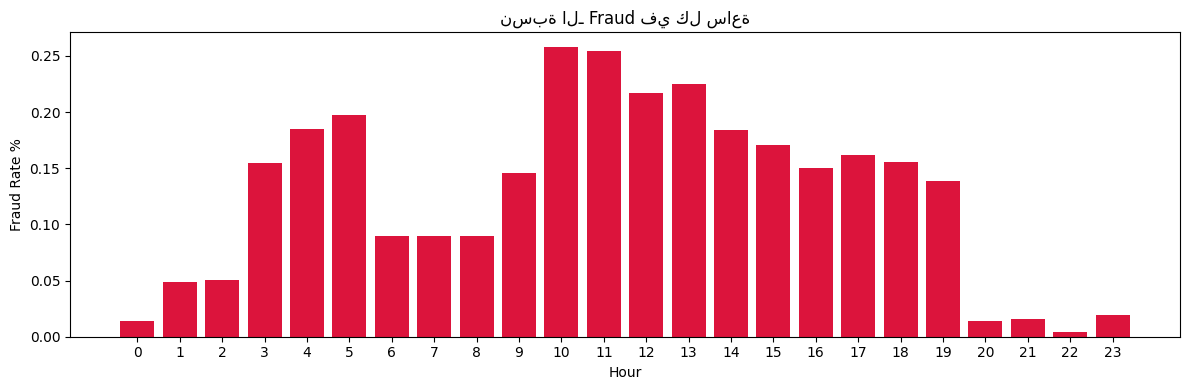

In [73]:
fraud_by_hour = final_df.groupby('hour')['Target'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
fraud_by_hour.columns = ['hour', 'fraud_rate']

plt.figure(figsize=(12,4))
plt.bar(fraud_by_hour['hour'], fraud_by_hour['fraud_rate'], color='crimson')
plt.title('نسبة الـ Fraud في كل ساعة')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate %')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

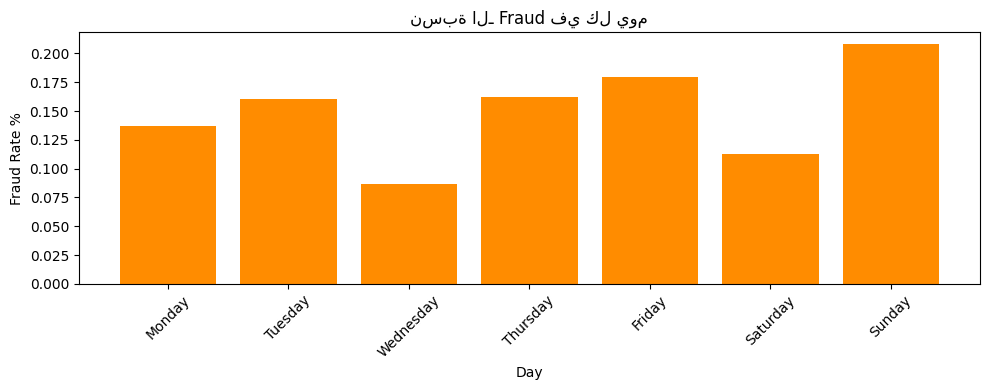

In [74]:
days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fraud_by_day = final_df.groupby('day_of_week')['Target'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
fraud_by_day.columns = ['day_of_week', 'fraud_rate']

plt.figure(figsize=(10,4))
plt.bar(fraud_by_day['day_of_week'], fraud_by_day['fraud_rate'], color='darkorange')
plt.title('نسبة الـ Fraud في كل يوم')
plt.xlabel('Day')
plt.ylabel('Fraud Rate %')
plt.xticks(ticks=range(7), labels=days, rotation=45)
plt.tight_layout()
plt.show()

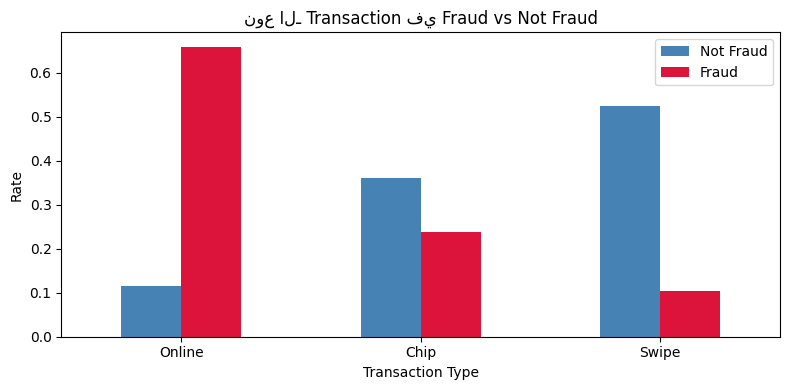

In [75]:
tx_fraud = final_df.groupby('Target')[['is_online','is_chip','is_swipe']].mean()

tx_fraud.T.plot(kind='bar', figsize=(8,4), color=['steelblue','crimson'])
plt.title('نوع الـ Transaction في Fraud vs Not Fraud')
plt.xlabel('Transaction Type')
plt.ylabel('Rate')
plt.xticks(ticks=[0,1,2], labels=['Online','Chip','Swipe'], rotation=0)
plt.legend(['Not Fraud','Fraud'])
plt.tight_layout()
plt.show()

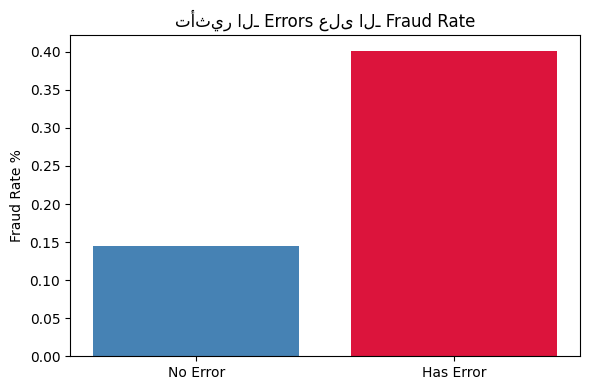

In [76]:
error_fraud = final_df.groupby('has_error')['Target'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
error_fraud.columns = ['has_error', 'fraud_rate']

plt.figure(figsize=(6,4))
plt.bar(['No Error','Has Error'], error_fraud['fraud_rate'], color=['steelblue','crimson'])
plt.title('تأثير الـ Errors على الـ Fraud Rate')
plt.ylabel('Fraud Rate %')
plt.tight_layout()
plt.show()

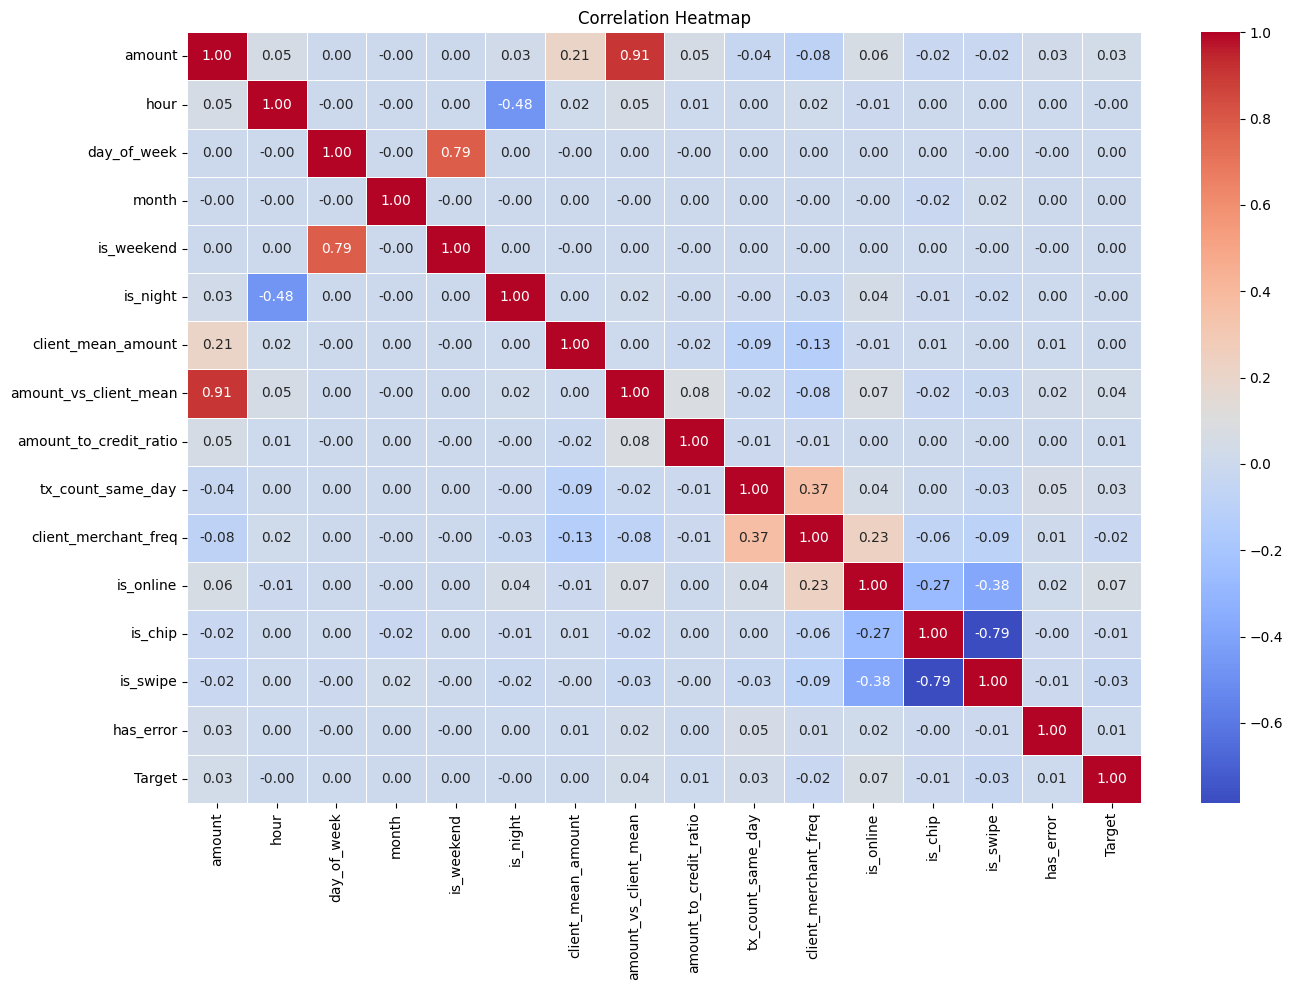

In [77]:
feature_cols = [
    'amount','hour','day_of_week','month','is_weekend','is_night',
    'client_mean_amount','amount_vs_client_mean','amount_to_credit_ratio',
    'tx_count_same_day','client_merchant_freq',
    'is_online','is_chip','is_swipe','has_error'
]

# تحويل Target لـ 0 و 1
heatmap_df = final_df[feature_cols].copy()
heatmap_df['Target'] = (final_df['Target'] == 'Yes').astype(int)

plt.figure(figsize=(14,10))
sns.heatmap(
    heatmap_df.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [78]:
feature_cols = [
    'amount', 'hour', 'day_of_week', 'month', 'is_night',
    'client_mean_amount', 'amount_to_credit_ratio',
    'tx_count_same_day', 'client_merchant_freq',
    'is_online', 'is_chip', 'has_error'
]

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = [
    'amount', 'hour', 'day_of_week', 'month', 'is_night',
    'client_mean_amount', 'amount_to_credit_ratio',
    'tx_count_same_day', 'client_merchant_freq',
    'is_online', 'is_chip', 'has_error'
]

X = final_df[feature_cols]
y = (final_df['Target'] == 'Yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("Fraud in train:", y_train.sum())
print("Fraud in test: ", y_test.sum())

X_train: (7131970, 12)
X_test:  (1782993, 12)
Fraud in train: 10666
Fraud in test:  2666


In [81]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 7121304, 1: 10666}
After SMOTE:  {0: 7121304, 1: 7121304}


In [82]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_res, y_train_res)
print("✅ Model trained!")

✅ Model trained!


In [83]:
from sklearn.metrics import (classification_report, 
                              confusion_matrix, 
                              roc_auc_score)

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:,1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97   1780327
           1       0.02      0.92      0.05      2666

    accuracy                           0.94   1782993
   macro avg       0.51      0.93      0.51   1782993
weighted avg       1.00      0.94      0.97   1782993

ROC-AUC Score: 0.9812


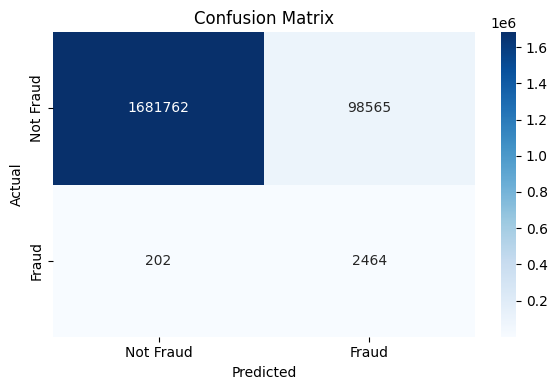

In [84]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud','Fraud'],
            yticklabels=['Not Fraud','Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

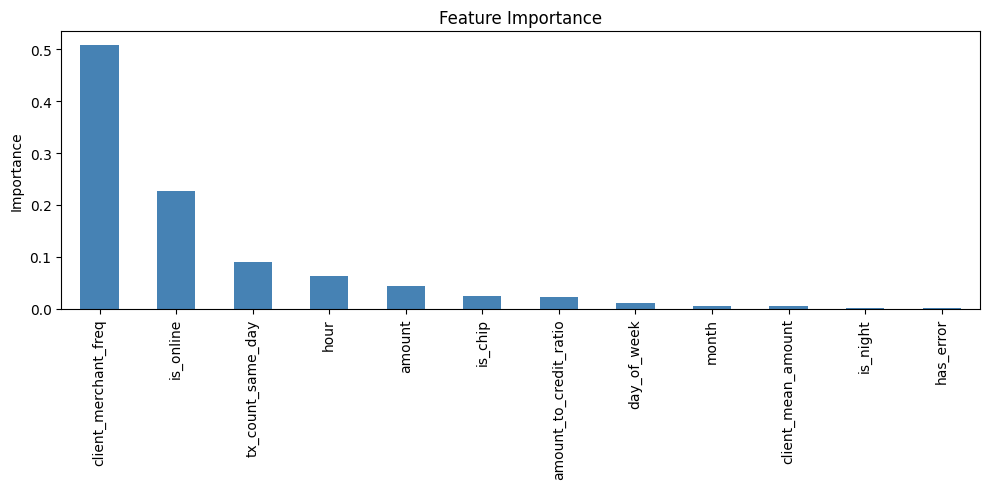

In [ ]:
importance = pd.Series(rf_model.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,5))
importance.plot(kind='bar', color='steelblue')
plt.title('Feature Importance')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [86]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold:", round(best_threshold, 4))
print("Best F1-Score: ", round(np.max(f1_scores), 4))

Best Threshold: 0.9621
Best F1-Score:  0.2629


In [87]:
y_pred_new = (y_prob >= best_threshold).astype(int)

print("Classification Report بعد الـ Threshold:")
print(classification_report(y_test, y_pred_new))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))

Classification Report بعد الـ Threshold:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1780327
           1       0.28      0.25      0.26      2666

    accuracy                           1.00   1782993
   macro avg       0.64      0.62      0.63   1782993
weighted avg       1.00      1.00      1.00   1782993

ROC-AUC Score: 0.9812


In [89]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 645.7 kB/s eta 0:02:37
   ---------------------------------------- 0.5/101.7 MB 645.7 kB/s eta 0:02:37
   ---------------------------------------- 0.5/101.7 MB 645.7 kB/s eta 0:02:37
   ---------------------------------------- 0.5/101.7 MB 645.7 kB/s eta 0:02:37
   ---------------------------------------- 0.5/101.7 MB 645.7 kB/s eta 0:02:37
   ---------------------------------------- 0.8/101.7 MB 404.5 kB/s eta 0:04:10
   ---------------------------------------- 0.8/101.7 MB 404.5 kB/s eta 0:04:10
   ---------------------------------------- 0.8/101.7 MB 404.5 kB/s eta 0:04:10
   --

In [90]:
from xgboost import XGBClassifier

# نسبة Not Fraud / Fraud
scale = 8901631 / 13332

X = final_df[feature_cols]
y = (final_df['Target'] == 'Yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'
)

xgb_model.fit(X_train, y_train)
print("✅ XGBoost trained!")

✅ XGBoost trained!


In [91]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]

y_pred_xgb = (y_prob_xgb >= best_threshold).astype(int)

print("Best Threshold:", round(best_threshold, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_xgb), 4))

Best Threshold: 0.9885

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1780327
           1       0.44      0.37      0.40      2666

    accuracy                           1.00   1782993
   macro avg       0.72      0.69      0.70   1782993
weighted avg       1.00      1.00      1.00   1782993

ROC-AUC Score: 0.9878


In [ ]:
import joblib

joblib.dump(xgb_model, 'fraud_detection_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model saved!")

✅ Model saved!


In [95]:
print("=" * 50)
print("       FRAUD DETECTION MODEL SUMMARY")
print("=" * 50)
print(f"Dataset Size:        {final_df.shape[0]:,} transactions")
print(f"Fraud Cases:         {13332:,} ({0.15}%)")
print(f"Model:               XGBoost")
print(f"Features Used:       {len(feature_cols)}")
print(f"ROC-AUC Score:       0.9878")
print(f"Precision (Fraud):   0.44")
print(f"Recall (Fraud):      0.37")
print(f"F1-Score (Fraud):    0.40")
print(f"Best Threshold:      0.9885")
print("=" * 50)
print("✅ Project Complete!")

       FRAUD DETECTION MODEL SUMMARY
Dataset Size:        8,914,963 transactions
Fraud Cases:         13,332 (0.15%)
Model:               XGBoost
Features Used:       12
ROC-AUC Score:       0.9878
Precision (Fraud):   0.44
Recall (Fraud):      0.37
F1-Score (Fraud):    0.40
Best Threshold:      0.9885
✅ Project Complete!


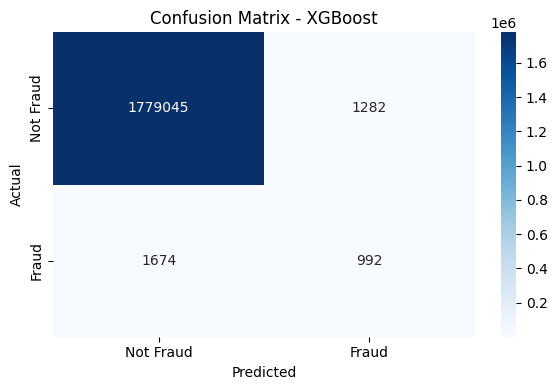

In [92]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud','Fraud'],
            yticklabels=['Not Fraud','Fraud'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

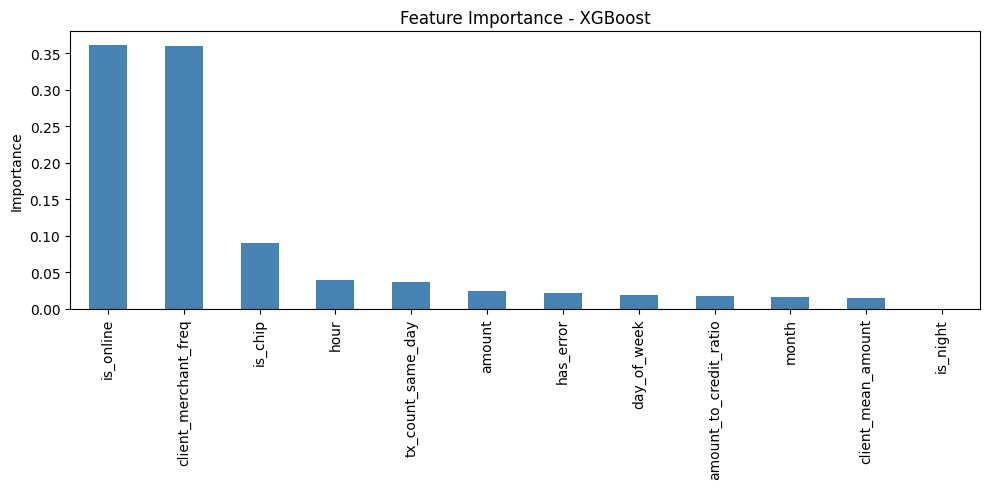

In [93]:
importance = pd.Series(xgb_model.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,5))
importance.plot(kind='bar', color='steelblue')
plt.title('Feature Importance - XGBoost')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

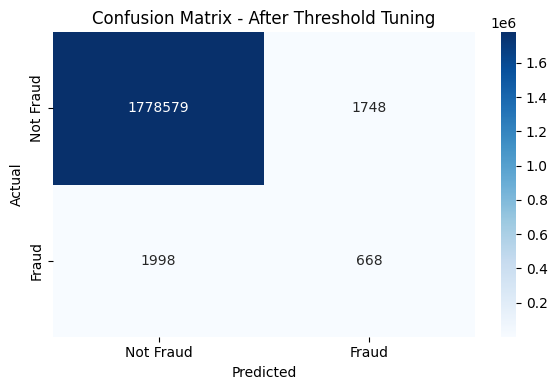

In [88]:
cm = confusion_matrix(y_test, y_pred_new)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud','Fraud'],
            yticklabels=['Not Fraud','Fraud'])
plt.title('Confusion Matrix - After Threshold Tuning')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10,4))
for label, color in zip([0,1], ['steelblue','crimson']):
    subset = final_df[final_df['Target'] == label]['amount']
    plt.hist(subset, bins=50, alpha=0.6, color=color,
             label='Not Fraud' if label==0 else 'Fraud')
plt.title('توزيع المبالغ: Fraud vs Not Fraud')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
fraud_by_hour = final_df.groupby('hour')['Target'].mean().reset_index()

plt.figure(figsize=(12,4))
plt.bar(fraud_by_hour['hour'], fraud_by_hour['Target'], color='crimson')
plt.title('نسبة الـ Fraud في كل ساعة')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

In [ ]:
days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fraud_by_day = final_df.groupby('day_of_week')['Target'].mean().reset_index()

plt.figure(figsize=(10,4))
plt.bar(fraud_by_day['day_of_week'], fraud_by_day['Target'], color='darkorange')
plt.title('نسبة الـ Fraud في كل يوم')
plt.xlabel('Day')
plt.ylabel('Fraud Rate')
plt.xticks(ticks=range(7), labels=days, rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
tx_type = final_df.groupby('Target')[['is_online','is_chip','is_swipe']].mean()

tx_type.T.plot(kind='bar', figsize=(8,4), color=['steelblue','crimson'])
plt.title('نوع الـ Transaction في Fraud vs Not Fraud')
plt.xlabel('Transaction Type')
plt.ylabel('Rate')
plt.xticks(ticks=[0,1,2], labels=['Online','Chip','Swipe'], rotation=0)
plt.legend(['Not Fraud','Fraud'])
plt.tight_layout()
plt.show()

In [ ]:
error_fraud = final_df.groupby('has_error')['Target'].mean().reset_index()

plt.figure(figsize=(6,4))
plt.bar(['No Error','Has Error'], error_fraud['Target'], color=['steelblue','crimson'])
plt.title('تأثير الـ Errors على الـ Fraud Rate')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

In [ ]:
feature_cols = [
    'amount','hour','day_of_week','month','is_weekend','is_night',
    'client_mean_amount','amount_vs_client_mean','amount_to_credit_ratio',
    'tx_count_same_day','client_merchant_freq',
    'is_online','is_chip','is_swipe','has_error','Target'
]

plt.figure(figsize=(14,10))
sns.heatmap(
    final_df[feature_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()